# Effect of outliers on SVM

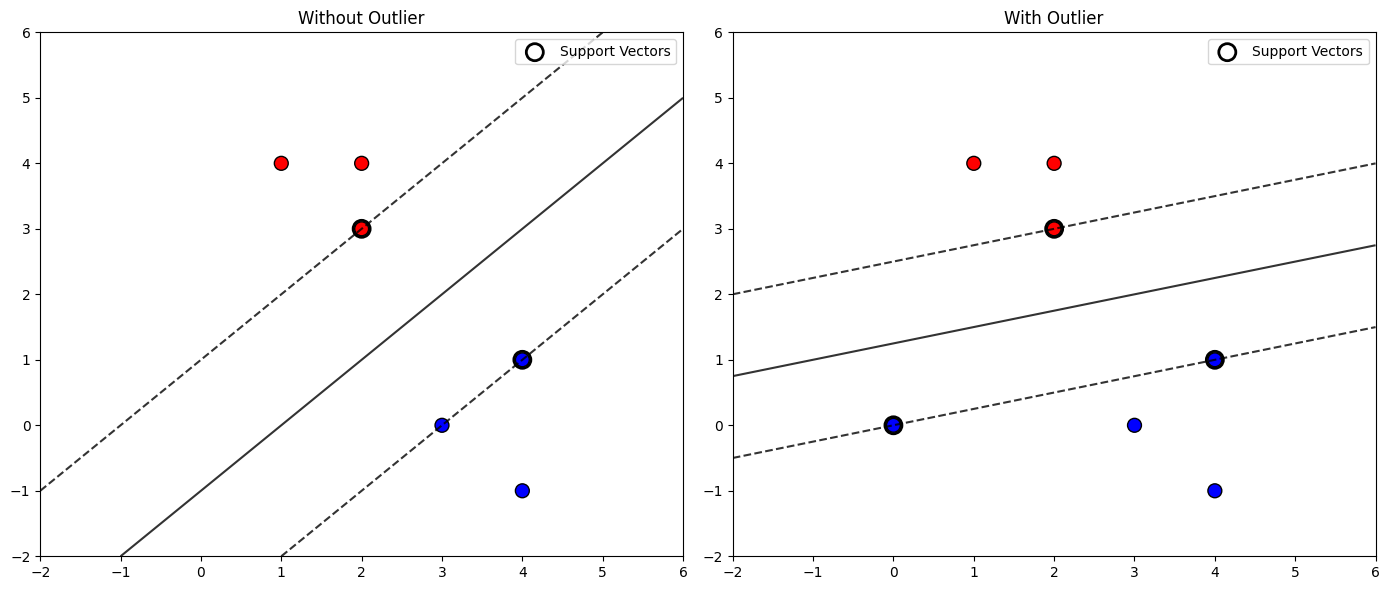

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

def plot_svm(X, y, model, title, subplot):
    ax = plt.subplot(1, 2, subplot)
    ax.set_title(title)
    ax.set_xlim(-2, 6)
    ax.set_ylim(-2, 6)

    # Scatter plot of the points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=100, edgecolors='k')
    
    # Plot support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=150, facecolors='none', edgecolors='k', linewidths=2, label='Support Vectors')

    # Create grid to evaluate model
    xx, yy = np.meshgrid(np.linspace(-2, 6, 100), np.linspace(-2, 6, 100))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary and margins
    ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.8,
               linestyles=['--', '-', '--'])

    ax.legend(loc='upper right')

# Step 1: Without outlier
X_clean = np.array([
    [1, 4], [2, 3], [2, 4],     # Class 1
    [3, 0], [4, 1], [4, -1]     # Class -1
])
y_clean = np.array([1, 1, 1, -1, -1, -1])

model_clean = SVC(kernel='linear', C=1000)  # Hard margin
model_clean.fit(X_clean, y_clean)

# Step 2: Add outlier
X_outlier = np.vstack([X_clean, [0, 0]])  # Add an outlier close to class -1
y_outlier = np.append(y_clean, -1)

model_outlier = SVC(kernel='linear', C=1000)
model_outlier.fit(X_outlier, y_outlier)

# Plotting
plt.figure(figsize=(14, 6))
plot_svm(X_clean, y_clean, model_clean, "Without Outlier", 1)
plot_svm(X_outlier, y_outlier, model_outlier, "With Outlier", 2)
plt.tight_layout()
plt.show()
